In [4]:

# ─────────────────────────────────────────────────────────────────────────────
#  CELL 1 — Setup  (run this first)
#  Uncomment the next line to install dependencies if needed:
#  !pip install plotly pandas wordcloud matplotlib kaleido
# ─────────────────────────────────────────────────────────────────────────────
import json, re, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image
warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────
ROOT  = Path(".")
DATA  = ROOT / "data"
ANLYS = DATA / "analysis"

def load_j(path, default=None):
    p = Path(path)
    try:
        return json.loads(p.read_text()) if p.exists() else ([] if default is None else default)
    except Exception:
        return [] if default is None else default

# ── Load entries ──────────────────────────────────────────────
raw     = load_j(DATA / "entries.json", {"entries": []})
entries = raw.get("entries", [])
df      = pd.DataFrame(entries) if entries else pd.DataFrame(
              columns=["llm","profile","qtype","total","scores"])

if not df.empty:
    for dim in ["D1","D2","D3","D4","D5"]:
        df[dim] = df["scores"].apply(lambda x: x.get(dim, 0) if isinstance(x, dict) else 0)
    df["total"] = pd.to_numeric(df["total"], errors="coerce").fillna(0).astype(int)

# ── Load analysis files ───────────────────────────────────────
sites    = load_j(ANLYS / "sites.json")
themes   = load_j(ANLYS / "themes.json")
impr     = load_j(ANLYS / "improvements.json", {"P1":[],"P2":[],"P3":[]})
good_fb  = load_j(ANLYS / "good_feedback.json")
bad_fb   = load_j(ANLYS / "bad_feedback.json")
insights = load_j(ANLYS / "insights.json")
wfreq    = load_j(ANLYS / "word_frequencies.json", {})

# ── Colour palette ────────────────────────────────────────────
GOLD = "#CFB87C";  GOLD_D = "#9a7c3c";  DARK = "#1a1a1a"

LLM_C = {
    "ChatGPT":    "#10a37f",
    "Gemini":     "#4285f4",
    "Perplexity": "#6366f1",
    "Copilot":    "#0078d4",
    "Claude":     "#d4670e",
}
PRF_C = {"A":"#8b5cf6","B":"#3b82f6","C":"#14b8a6","D":"#f59e0b","D1":"#10b981"}
PRF_N = {"A":"Career Changer","B":"Working Professional",
         "C":"International Student","D":"Undergrad→Grad","D1":"CU Undergrad"}
P_C   = {"P1":"#dc2626","P2":"#d97706","P3":"#059669"}
P_BG  = {"P1":"#fef2f2","P2":"#fffbeb","P3":"#f0fdf4"}
P_BR  = {"P1":"#fecaca","P2":"#fde68a","P3":"#a7f3d0"}

# BASE holds default layout props shared across every chart.
# Use L(**overrides) instead of **BASE directly — it lets you override
# any key without Python raising "multiple values for keyword argument".
BASE = dict(
    font=dict(family="Segoe UI, Inter, Arial, sans-serif", size=13, color=DARK),
    paper_bgcolor="white", plot_bgcolor="#f9fafb",
    hoverlabel=dict(bgcolor="white", bordercolor="#e2e8f0", font_size=13),
    margin=dict(l=20, r=20, t=70, b=20),
    title_font=dict(size=17, color=DARK),
)

def L(**kw):
    """Return BASE merged with kw — kw always wins on duplicate keys."""
    return {**BASE, **kw}

def section(title, subtitle="", color=GOLD, icon="▸"):
    display(HTML(f"""
    <div style="background:linear-gradient(135deg,{color}28,{color}06);
      border-left:5px solid {color};border-radius:12px;padding:18px 28px;
      margin:44px 0 14px;box-shadow:0 2px 12px rgba(0,0,0,.06);
      font-family:Segoe UI,Inter,sans-serif;">
      <h2 style="margin:0 0 3px;font-size:21px;font-weight:800;color:{DARK};letter-spacing:-.4px;">
        {icon}&nbsp; {title}
      </h2>
      {"<p style='margin:0;font-size:13px;color:#64748b;font-weight:500;'>"+subtitle+"</p>" if subtitle else ""}
    </div>"""))

print(f"✓  {len(df)} entries · {df['llm'].nunique() if not df.empty else 0} LLMs "
      f"· {df['profile'].nunique() if not df.empty else 0} profiles")
print(f"✓  {len(sites)} sites · {len(themes)} themes · "
      f"{len(good_fb)} positive · {len(bad_fb)} negative · {len(insights)} insights")
print(f"✓  Improvements — P1: {len(impr.get('P1',[]))} · "
      f"P2: {len(impr.get('P2',[]))} · P3: {len(impr.get('P3',[]))}")


✓  99 entries · 4 LLMs · 5 profiles
✓  142 sites · 141 themes · 77 positive · 130 negative · 146 insights
✓  Improvements — P1: 76 · P2: 73 · P3: 69


In [5]:

# ── CELL 2 — Hero banner + KPI cards ─────────────────────────
avg      = df["total"].mean() if not df.empty else 0
top_llm  = df.groupby("llm")["total"].mean().idxmax()  if not df.empty else "—"
top_prof = df.groupby("profile")["total"].mean().idxmax() if not df.empty else "—"
n_p1     = len(impr.get("P1", []))

def kpi(val, label, color=GOLD):
    return f"""
    <div style="text-align:center;padding:14px 22px;background:rgba(255,255,255,.07);
                border-radius:10px;min-width:95px;">
      <div style="font-size:32px;font-weight:900;color:{color};line-height:1.05;">{val}</div>
      <div style="font-size:9.5px;color:rgba(255,255,255,.4);text-transform:uppercase;
                  letter-spacing:.8px;margin-top:5px;">{label}</div>
    </div>"""

sep = "<div style='width:1px;height:52px;background:rgba(255,255,255,.1);'></div>"

display(HTML(f"""
<div style="background:linear-gradient(135deg,#1a1a1a 0%,#2d2d2d 55%,#3d3020 100%);
  border-radius:18px;padding:44px 52px 36px;margin-bottom:10px;
  border-bottom:5px solid {GOLD};font-family:Segoe UI,Inter,sans-serif;
  box-shadow:0 12px 48px rgba(0,0,0,.22);">
  <div style="display:flex;gap:10px;margin-bottom:18px;">
    <span style="background:{GOLD};color:#1a1a1a;font-size:10px;font-weight:800;
                 padding:3px 13px;border-radius:99px;letter-spacing:.8px;">CU BOULDER · MSDS</span>
    <span style="background:rgba(255,255,255,.1);color:rgba(255,255,255,.45);font-size:10px;
                 font-weight:700;padding:3px 13px;border-radius:99px;letter-spacing:.7px;">RESEARCH TOOL</span>
  </div>
  <h1 style="color:#fff;font-size:46px;font-weight:900;margin:0 0 10px;letter-spacing:-2px;line-height:1.05;">
    LLM Audit Analysis
  </h1>
  <p style="color:rgba(207,184,124,.7);font-size:16px;margin:0 0 36px;font-weight:500;line-height:1.5;">
    Examining how AI chatbots represent the MS Data Science program —
    across 5&nbsp;LLMs, 5&nbsp;student profiles &amp; 5&nbsp;query types
  </p>
  <div style="display:flex;gap:14px;flex-wrap:wrap;align-items:center;">
    {kpi(len(df), "Total Entries")}
    {sep}
    {kpi(df["llm"].nunique() if not df.empty else 0, "LLMs Tested")}
    {sep}
    {kpi(df["profile"].nunique() if not df.empty else 0, "Student Profiles")}
    {sep}
    {kpi(f"{avg:.1f} / 15", "Avg Score", "#86efac")}
    {sep}
    {kpi(top_llm, "Best LLM", "#93c5fd")}
    {sep}
    {kpi(len(themes), "Recurring Themes", "#c4b5fd")}
    {sep}
    {kpi(n_p1, "P1 Issues", "#fca5a5")}
  </div>
</div>"""))


In [6]:

# ── CELL 3 — Score heatmap (LLM × Profile) ───────────────────
section("Score Overview", "Average total score (out of 15) by LLM and student profile", GOLD, "🎯")

if not df.empty:
    pivot = df.pivot_table(values="total", index="llm", columns="profile", aggfunc="mean")
    pivot = pivot.reindex(columns=[c for c in ["A","B","C","D","D1"] if c in pivot.columns])
    pivot.columns = [PRF_N.get(c, c) for c in pivot.columns]

    col_scale = [
        [0.00, "#7f1d1d"], [0.20, "#dc2626"],
        [0.40, "#fb923c"], [0.50, "#fbbf24"],
        [0.67, "#86efac"], [0.83, "#22c55e"],
        [1.00, "#14532d"],
    ]

    fig = go.Figure(go.Heatmap(
        z=pivot.values, x=list(pivot.columns), y=list(pivot.index),
        text=np.round(pivot.values, 1),
        texttemplate="<b>%{text}</b>", textfont=dict(size=16, color="white"),
        colorscale=col_scale, zmin=0, zmax=15,
        colorbar=dict(
            title=dict(text="Score / 15", font=dict(size=12)),
            tickvals=[0, 5, 7.5, 10, 15],
            ticktext=["0 (worst)", "5", "7.5", "10", "15 (best)"],
            len=0.9, thickness=18,
        ),
        hovertemplate="<b>%{y}</b> → <b>%{x}</b><br>Avg score: %{z:.1f} / 15<extra></extra>",
    ))
    fig.update_layout(**L(
        title="Average Score by LLM × Student Profile",
        xaxis=dict(tickfont=dict(size=13), side="top", tickangle=0, gridcolor="white"),
        yaxis=dict(tickfont=dict(size=13), autorange="reversed", gridcolor="white"),
        plot_bgcolor="white", height=400,
    ))
    fig.show()

    # Per-LLM ranked bar
    llm_stats = (df.groupby("llm")["total"]
                   .agg(["mean","std","count"]).round(2).reset_index()
                   .sort_values("mean", ascending=True))

    fig2 = go.Figure(go.Bar(
        x=llm_stats["mean"], y=llm_stats["llm"],
        orientation="h",
        marker=dict(color=[LLM_C.get(l, GOLD) for l in llm_stats["llm"]],
                    line=dict(width=0)),
        error_x=dict(array=llm_stats["std"], color="#94a3b8", thickness=2, width=7),
        text=[f"<b>{v:.1f}</b>" for v in llm_stats["mean"]],
        textposition="auto", textfont=dict(color="white", size=13),
        customdata=llm_stats[["count","std"]].values,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Avg score: %{x:.2f} / 15<br>"
            "Std dev: %{customdata[1]:.2f}<br>"
            "Entries: %{customdata[0]}<extra></extra>"
        ),
    ))
    fig2.add_vline(x=df["total"].mean(), line_dash="dash",
                   line_color="#94a3b8", line_width=1.5,
                   annotation_text=f"  Overall avg ({df['total'].mean():.1f})",
                   annotation_font_size=11, annotation_font_color="#64748b")
    fig2.update_layout(**L(
        title="Average Score by LLM with Standard Deviation",
        xaxis=dict(title="Score / 15", range=[0, 15], gridcolor="#e5e7eb"),
        yaxis=dict(title=""),
        height=320, bargap=0.38, plot_bgcolor="white",
    ))
    fig2.show()


In [16]:

# ── CELL 4 — Dimension deep-dive: radar + grouped bar ────────
section("Scoring Dimensions", "How each LLM performs across Visibility, Accuracy, Completeness, Relevance & Sentiment", "#3b82f6", "📊")

if not df.empty:
    dims       = ["D1","D2","D3","D4","D5"]
    dim_labels = ["Visibility","Accuracy","Completeness","Relevance","Sentiment"]

    # ── Radar chart (one trace per LLM) ──────────────────────
    fig = go.Figure()
    for llm, color in LLM_C.items():
        if llm not in df["llm"].values:
            continue
        sub  = df[df["llm"] == llm]
        vals = [sub[d].mean() / 3 * 100 for d in dims]
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]],
            theta=dim_labels + [dim_labels[0]],
            name=llm, fill="toself",
            line=dict(color=color, width=2.5),
            # fillcolor=color + "22",
            hovertemplate="<b>" + llm + "</b><br>%{theta}: %{r:.0f}%<extra></extra>",
        ))
    fig.update_layout(**L(
        title="Dimension Performance by LLM  (% of max per dimension)",
        polar=dict(
            bgcolor="#f9fafb",
            radialaxis=dict(visible=True, range=[0, 100], ticksuffix="%",
                            tickfont=dict(size=10), gridcolor="#e5e7eb"),
            angularaxis=dict(tickfont=dict(size=13, color=DARK), gridcolor="#e5e7eb"),
        ),
        legend=dict(orientation="h", y=-0.18, x=0.5, xanchor="center", font=dict(size=12)),
        height=520, paper_bgcolor="white",
    ))
    fig.show()

    # ── Grouped bar: profile × dimension ─────────────────────
    dim_colors = [GOLD, "#3b82f6", "#10b981", "#8b5cf6", "#f59e0b"]
    prof_dim   = df.groupby("profile")[dims].mean()

    fig2 = go.Figure()
    for dim, label, color in zip(dims, dim_labels, dim_colors):
        fig2.add_trace(go.Bar(
            name=label,
            x=[PRF_N.get(p, p) for p in prof_dim.index],
            y=prof_dim[dim],
            marker_color=color,
            hovertemplate=f"<b>{label}</b><br>%{{x}}: %{{y:.2f}} / 3<extra></extra>",
        ))
    fig2.update_layout(**L(
        title="Average Dimension Score by Student Profile",
        barmode="group", bargap=0.22, bargroupgap=0.04,
        yaxis=dict(title="Score (0–3)", range=[0, 3.3], gridcolor="#e5e7eb"),
        xaxis=dict(title=""),
        legend=dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
        height=380, plot_bgcolor="white",
    ))
    fig2.show()

    # ── Score distribution violin by LLM ─────────────────────
    fig3 = go.Figure()
    for llm, color in LLM_C.items():
        sub = df[df["llm"] == llm]["total"]
        if sub.empty:
            continue
        fig3.add_trace(go.Violin(
            y=sub, name=llm,
            # fillcolor=color + "55", 
            line_color=color,
            box_visible=True, meanline_visible=True,
            points="all", pointpos=0,
            marker=dict(size=4, color=color, opacity=0.5),
            hovertemplate="<b>" + llm + "</b><br>Score: %{y}<extra></extra>",
        ))
    fig3.add_hline(y=df["total"].mean(), line_dash="dash",
                   line_color="#94a3b8", line_width=1.5,
                   annotation_text=f"  Mean = {df['total'].mean():.1f}",
                   annotation_font_color="#64748b")
    fig3.update_layout(**L(
        title="Score Distribution per LLM",
        yaxis=dict(title="Total Score / 15", range=[0, 16], gridcolor="#e5e7eb"),
        xaxis=dict(title=""),
        height=420, plot_bgcolor="white", violingap=0.3,
    ))
    fig3.show()


In [8]:

# ── CELL 5 — Most referenced sources ─────────────────────────
section("Most Referenced Sources", f"{len(sites)} unique domains cited across all LLM responses", "#14b8a6", "🔗")

def clean_domain(url):
    try:
        u = url if url.startswith("http") else "https://" + url
        dom = re.sub(r"^www\.", "", re.sub(r"https?://(www\.)?", "", u).split("/")[0].split("?")[0])
        return dom[:50]
    except Exception:
        return str(url)[:50]

def domain_color(url):
    u = url.lower()
    if "colorado.edu" in u:                        return GOLD
    if "reddit.com" in u:                          return "#ff4500"
    if "coursera" in u:                            return "#0056d2"
    if "linkedin" in u:                            return "#0a66c2"
    if "usnews" in u or "ranking" in u:            return "#c41230"
    if any(x in u for x in ["indiana","iu.edu"]): return "#990000"
    if "syracuse" in u:                            return "#f76900"
    if "gatech" in u or "georgia" in u:            return "#003057"
    if "washington" in u or "uw.edu" in u:         return "#4b2e83"
    if ".edu" in u:                                return "#475569"
    return "#6366f1"

def categorize_url(url):
    u = url.lower()
    if "colorado.edu" in u: return "CU Boulder Official"
    if "reddit.com" in u:   return "Reddit / Community"
    if "usnews" in u or "ranking" in u or "niche" in u or "grad" in u: return "Rankings"
    if any(x in u for x in ["coursera","edx","udemy","khanacademy"]): return "Learning Platforms"
    if ".edu" in u:         return "Other Universities"
    return "Other"

if sites:
    s_df = pd.DataFrame(sites)
    s_df["domain"]   = s_df["url"].apply(clean_domain)
    s_df["color"]    = s_df["url"].apply(domain_color)
    s_df["category"] = s_df["url"].apply(categorize_url)
    top25 = s_df.sort_values("frequency", ascending=False).head(25).sort_values("frequency")

    fig = go.Figure(go.Bar(
        x=top25["frequency"], y=top25["domain"],
        orientation="h",
        marker=dict(color=top25["color"].tolist(), line=dict(width=0)),
        text=[f"<b>{v}</b>" for v in top25["frequency"]],
        textposition="auto", textfont=dict(size=12),
        customdata=top25[["url","context"]].values if "context" in top25.columns
                   else top25[["url","url"]].values,
        hovertemplate="<b>%{y}</b><br>Cited: %{x}×<br>%{customdata[1]}<extra></extra>",
    ))
    fig.update_layout(**L(
        title="Top 25 Cited Domains Across All LLM Responses",
        xaxis=dict(title="Times Referenced", gridcolor="#e5e7eb"),
        yaxis=dict(title="", tickfont=dict(size=10.5)),
        height=700, plot_bgcolor="white",
    ))
    fig.show()

    # Category donut
    cat_grp = s_df.groupby("category")["frequency"].sum().reset_index().sort_values("frequency", ascending=False)
    pie_colors = [GOLD, "#ff4500", "#c41230", "#0056d2", "#475569", "#6366f1"]
    fig2 = go.Figure(go.Pie(
        labels=cat_grp["category"], values=cat_grp["frequency"],
        hole=0.52,
        marker=dict(colors=pie_colors[:len(cat_grp)], line=dict(color="white", width=3)),
        textfont=dict(size=12),
        hovertemplate="<b>%{label}</b><br>Citations: %{value}<br>%{percent}<extra></extra>",
    ))
    total_cit = cat_grp["frequency"].sum()
    fig2.add_annotation(text=f"<b>{total_cit:,}</b><br>total<br>citations",
                        x=0.5, y=0.5, showarrow=False, font=dict(size=13, color=DARK))
    fig2.update_layout(**L(
        title="Source Category Breakdown",
        height=380, legend=dict(orientation="h", y=-0.1, x=0.5, xanchor="center"),
    ))
    fig2.show()


In [9]:

# ── CELL 6 — Recurring themes ─────────────────────────────────
section("Recurring Themes", f"{len(themes)} themes identified across all responses — sized and coloured by frequency", "#8b5cf6", "🔁")

if themes:
    t_df = pd.DataFrame(themes)
    if "frequency" not in t_df.columns:
        t_df["frequency"] = 1
    t_df = t_df.sort_values("frequency", ascending=False)

    # ── Top-20 horizontal bar ─────────────────────────────────
    top20 = t_df.head(20).sort_values("frequency")
    q75   = top20["frequency"].quantile(0.75)
    q50   = top20["frequency"].quantile(0.50)
    bar_colors = ["#8b5cf6" if f >= q75 else "#a78bfa" if f >= q50 else "#c4b5fd"
                  for f in top20["frequency"]]

    fig = go.Figure(go.Bar(
        x=top20["frequency"], y=top20["theme"],
        orientation="h",
        marker=dict(color=bar_colors, line=dict(width=0)),
        text=[f"<b>{v}</b>" for v in top20["frequency"]],
        textposition="auto", textfont=dict(size=12),
        customdata=top20["description"].values if "description" in top20.columns else top20["theme"].values,
        hovertemplate="<b>%{y}</b><br>Frequency: %{x}<br><i>%{customdata}</i><extra></extra>",
    ))
    fig.update_layout(**L(
        title="Top 20 Recurring Themes",
        xaxis=dict(title="Frequency", gridcolor="#e5e7eb"),
        yaxis=dict(title="", tickfont=dict(size=11.5)),
        height=580, plot_bgcolor="white",
    ))
    fig.show()

    # ── Treemap of top 40 ─────────────────────────────────────
    top40 = t_df.head(40).copy()
    if "description" not in top40.columns:
        top40["description"] = top40["theme"]
    fig2 = go.Figure(go.Treemap(
        labels=top40["theme"],
        values=top40["frequency"],
        parents=[""] * len(top40),
        customdata=top40["description"].values,
        hovertemplate="<b>%{label}</b><br>Frequency: %{value}<br>%{customdata}<extra></extra>",
        marker=dict(
            colorscale=[[0, "#ede9fe"], [0.4, "#8b5cf6"], [1, "#3b0764"]],
            showscale=True,
            colorbar=dict(title="Frequency", thickness=14, len=0.8),
        ),
        textfont=dict(size=12, color="white"),
        tiling=dict(packing="squarify"),
    ))
    fig2.update_layout(**L(
        title="Themes Treemap — Top 40 (area ∝ frequency)",
        height=450, margin=dict(l=10, r=10, t=60, b=10),
    ))
    fig2.show()


In [10]:

# ── CELL 7 — Improvements (P1 / P2 / P3) ────────────────────
section("Recommended Improvements", "Content and representation gaps — classified by priority", "#dc2626", "⚠️")

impr_d = impr if isinstance(impr, dict) else {"P1":[],"P2":[],"P3":[]}

PLABEL = {"P1":"🔴 P1 — Critical",      "P2":"🟡 P2 — Moderate",     "P3":"🟢 P3 — Low Priority"}
PSUB   = {
    "P1": "Issues actively harming CU Boulder's visibility or introducing inaccuracies",
    "P2": "Significant content gaps that weaken the program's competitive position",
    "P3": "Minor tone, framing, or completeness improvements",
}

# ── Summary bar ───────────────────────────────────────────────
counts = {p: len(impr_d.get(p,[])) for p in ["P1","P2","P3"]}
fig_sum = go.Figure(go.Bar(
    x=list(counts.keys()), y=list(counts.values()),
    marker=dict(color=[P_C["P1"], P_C["P2"], P_C["P3"]], line=dict(width=0)),
    text=[f"<b>{v}</b>" for v in counts.values()],
    textposition="outside", textfont=dict(size=16),
    width=0.45,
))
fig_sum.update_layout(**L(
    title="Improvement Items by Priority",
    yaxis=dict(title="Number of Items", gridcolor="#e5e7eb", range=[0, max(counts.values())*1.18]),
    xaxis=dict(title=""), height=300, plot_bgcolor="white",
))
fig_sum.show()

# ── Cards per priority ────────────────────────────────────────
for pri in ["P1","P2","P3"]:
    items = impr_d.get(pri, [])[:15]
    if not items:
        continue
    total = len(impr_d.get(pri, []))

    cards_html = "".join(f"""
    <div style="background:white;border:1px solid {P_BR[pri]};border-radius:9px;
                padding:13px 16px;margin-bottom:9px;
                box-shadow:0 1px 5px rgba(0,0,0,.05);">
      <div style="font-weight:700;font-size:13.5px;color:{DARK};margin-bottom:4px;">
        {item.get('issue','—')}
      </div>
      <div style="font-size:12px;color:#64748b;line-height:1.55;">
        {item.get('rationale','—')}
      </div>
    </div>""" for item in items)

    overflow = (f"<p style='margin:8px 0 0;font-size:11px;color:#94a3b8;text-align:center;'>"
                f"Showing 15 of {total} items</p>" if total > 15 else "")

    display(HTML(f"""
    <div style="background:{P_BG[pri]};border:1.5px solid {P_BR[pri]};border-radius:14px;
                padding:22px 26px;margin-bottom:22px;font-family:Segoe UI,Inter,sans-serif;">
      <div style="display:flex;align-items:center;gap:12px;margin-bottom:6px;">
        <span style="background:{P_C[pri]};color:white;font-size:10px;font-weight:800;
                     padding:3px 12px;border-radius:99px;letter-spacing:.7px;">{pri}</span>
        <span style="font-size:19px;font-weight:800;color:{P_C[pri]};">{PLABEL[pri]}</span>
        <span style="margin-left:auto;font-size:12px;font-weight:700;color:{P_C[pri]};
                     background:{P_BR[pri]};padding:3px 10px;border-radius:99px;">{total} items</span>
      </div>
      <p style="margin:0 0 16px;font-size:12.5px;color:#64748b;">{PSUB[pri]}</p>
      {cards_html}{overflow}
    </div>"""))


In [14]:

# ── CELL 8 — Good vs Bad feedback ────────────────────────────
section("Feedback Summary", "Recurring positive and negative points about CU Boulder across all LLM responses", "#10b981", "💬")

if good_fb or bad_fb:
    gdf = pd.DataFrame(good_fb) if good_fb else pd.DataFrame(columns=["point","frequency"])
    bdf = pd.DataFrame(bad_fb)  if bad_fb  else pd.DataFrame(columns=["point","frequency"])
    if "frequency" not in gdf.columns: gdf["frequency"] = 1
    if "frequency" not in bdf.columns: bdf["frequency"] = 1

    top_g = gdf.nlargest(15, "frequency").sort_values("frequency")
    top_b = bdf.nlargest(15, "frequency").sort_values("frequency")

    fig = make_subplots(rows=1, cols=2,
        subplot_titles=("✅  Positive Mentions", "❌  Negative / Missing"),
        horizontal_spacing=0.1)

    if not top_g.empty:
        fig.add_trace(go.Bar(
            x=top_g["frequency"], y=top_g["point"],
            orientation="h", name="Positive",
            marker=dict(color="#22c55e", line=dict(width=0)),
            text=[f"<b>{v}</b>" for v in top_g["frequency"]],
            textposition="auto", textfont=dict(size=11),
            hovertemplate="<b>%{y}</b><br>Mentions: %{x}<extra></extra>",
        ), row=1, col=1)

    if not top_b.empty:
        fig.add_trace(go.Bar(
            x=top_b["frequency"], y=top_b["point"],
            orientation="h", name="Negative",
            marker=dict(color="#ef4444", line=dict(width=0)),
            text=[f"<b>{v}</b>" for v in top_b["frequency"]],
            textposition="auto", textfont=dict(size=11),
            hovertemplate="<b>%{y}</b><br>Mentions: %{x}<extra></extra>",
        ), row=1, col=2)

    fig.update_layout(**L(
        showlegend=False, height=560, plot_bgcolor="white",
        title="Recurring Feedback About CU Boulder's Representation",
    ))
    fig.update_xaxes(title_text="Frequency", gridcolor="#e5e7eb")
    fig.update_yaxes(tickfont=dict(size=9.5))
    fig.show()

    # ── Balance donut ─────────────────────────────────────────
    pos_total = int(gdf["frequency"].sum())
    neg_total = int(bdf["frequency"].sum())
    ratio     = pos_total / max(pos_total + neg_total, 1)
    sentiment = "Positive 🟢" if ratio > 0.55 else "Mixed 🟡" if ratio > 0.38 else "Negative 🔴"

    fig2 = go.Figure(go.Pie(
        labels=["Positive mentions", "Negative / missing"],
        values=[pos_total, neg_total],
        hole=0.56,
        marker=dict(colors=["#22c55e", "#ef4444"], line=dict(color="white", width=4)),
        textfont=dict(size=13),
        hovertemplate="<b>%{label}</b><br>Total: %{value:,}<br>%{percent}<extra></extra>",
    ))
    fig2.add_annotation(
        text=f"<b>{sentiment}</b><br>overall",
        x=0.5, y=0.5, showarrow=False, font=dict(size=14, color=DARK))
    fig2.update_layout(**L(
        title="Positive vs Negative Feedback Balance",
        height=360,
        legend=dict(orientation="h", y=-0.1, x=0.5, xanchor="center"),
    ))
    fig2.show()


In [12]:

# ── CELL 9 — Key insights ─────────────────────────────────────
section("Key Insights", f"{len(insights)} non-obvious findings — grouped by importance and category", "#f59e0b", "💡")

IMP_ORDER = ["high", "medium", "low"]
IMP_LABEL = {"high": "🔴 High Importance", "medium": "🟡 Medium Importance", "low": "🟢 Low Importance"}
IMP_BG    = {"high": "#fef2f2", "medium": "#fffbeb", "low": "#f0fdf4"}
IMP_BR    = {"high": "#fecaca", "medium": "#fde68a", "low": "#a7f3d0"}
IMP_C2    = {"high": "#dc2626", "medium": "#d97706", "low": "#059669"}
CAT_ICON  = {"visibility":"👁","accuracy":"✓","competitor":"⚔","content_gap":"📭",
             "content":"📭","sentiment":"💬","other":"•"}

if insights:
    ins_df = pd.DataFrame(insights)
    if "importance" not in ins_df.columns: ins_df["importance"] = "medium"
    if "category"   not in ins_df.columns: ins_df["category"]   = "other"

    # ── Sunburst: importance → category ──────────────────────
    ct = ins_df.groupby(["importance","category"]).size().reset_index(name="count")
    fig = px.sunburst(ct, path=["importance","category"], values="count",
        color="importance",
        color_discrete_map={"high":"#dc2626","medium":"#d97706","low":"#059669"},
        title="Insights — Importance × Category")
    fig.update_traces(textfont=dict(size=12),
                      hovertemplate="<b>%{label}</b><br>%{value} insights<extra></extra>")
    fig.update_layout(**L(height=400))
    fig.show()

    # ── Styled cards by importance tier ──────────────────────
    for imp in IMP_ORDER:
        subset = [i for i in insights if i.get("importance","") == imp][:12]
        if not subset:
            continue
        total = len([x for x in insights if x.get("importance","") == imp])

        cards = "".join(f"""
        <div style="display:flex;gap:12px;background:white;
                    border:1px solid {IMP_BR[imp]};border-radius:9px;
                    padding:13px 15px;margin-bottom:9px;
                    box-shadow:0 1px 5px rgba(0,0,0,.04);">
          <div style="font-size:22px;flex-shrink:0;padding-top:1px;line-height:1;">
            {CAT_ICON.get(item.get("category","other"), "•")}
          </div>
          <div>
            <div style="font-size:13.5px;font-weight:700;color:{DARK};
                        line-height:1.4;margin-bottom:3px;">
              {item.get("insight","—")}
            </div>
            <span style="font-size:10px;font-weight:700;color:{IMP_C2[imp]};
                         text-transform:uppercase;letter-spacing:.5px;
                         background:{IMP_BR[imp]};padding:2px 8px;border-radius:99px;">
              {item.get("category","—").replace("_"," ")}
            </span>
          </div>
        </div>""" for item in subset)

        overflow = (f"<p style='margin:8px 0 0;font-size:11px;color:#94a3b8;text-align:center;'>"
                    f"Showing 12 of {total} insights</p>" if total > 12 else "")

        display(HTML(f"""
        <div style="background:{IMP_BG[imp]};border:1.5px solid {IMP_BR[imp]};
                    border-radius:14px;padding:20px 24px;margin-bottom:20px;
                    font-family:Segoe UI,Inter,sans-serif;">
          <div style="display:flex;align-items:center;margin-bottom:14px;">
            <span style="font-size:18px;font-weight:800;color:{IMP_C2[imp]};">
              {IMP_LABEL[imp]}
            </span>
            <span style="margin-left:auto;font-size:12px;font-weight:700;
                         color:{IMP_C2[imp]};background:{IMP_BR[imp]};
                         padding:3px 10px;border-radius:99px;">{total} insights</span>
          </div>
          {cards}{overflow}
        </div>"""))


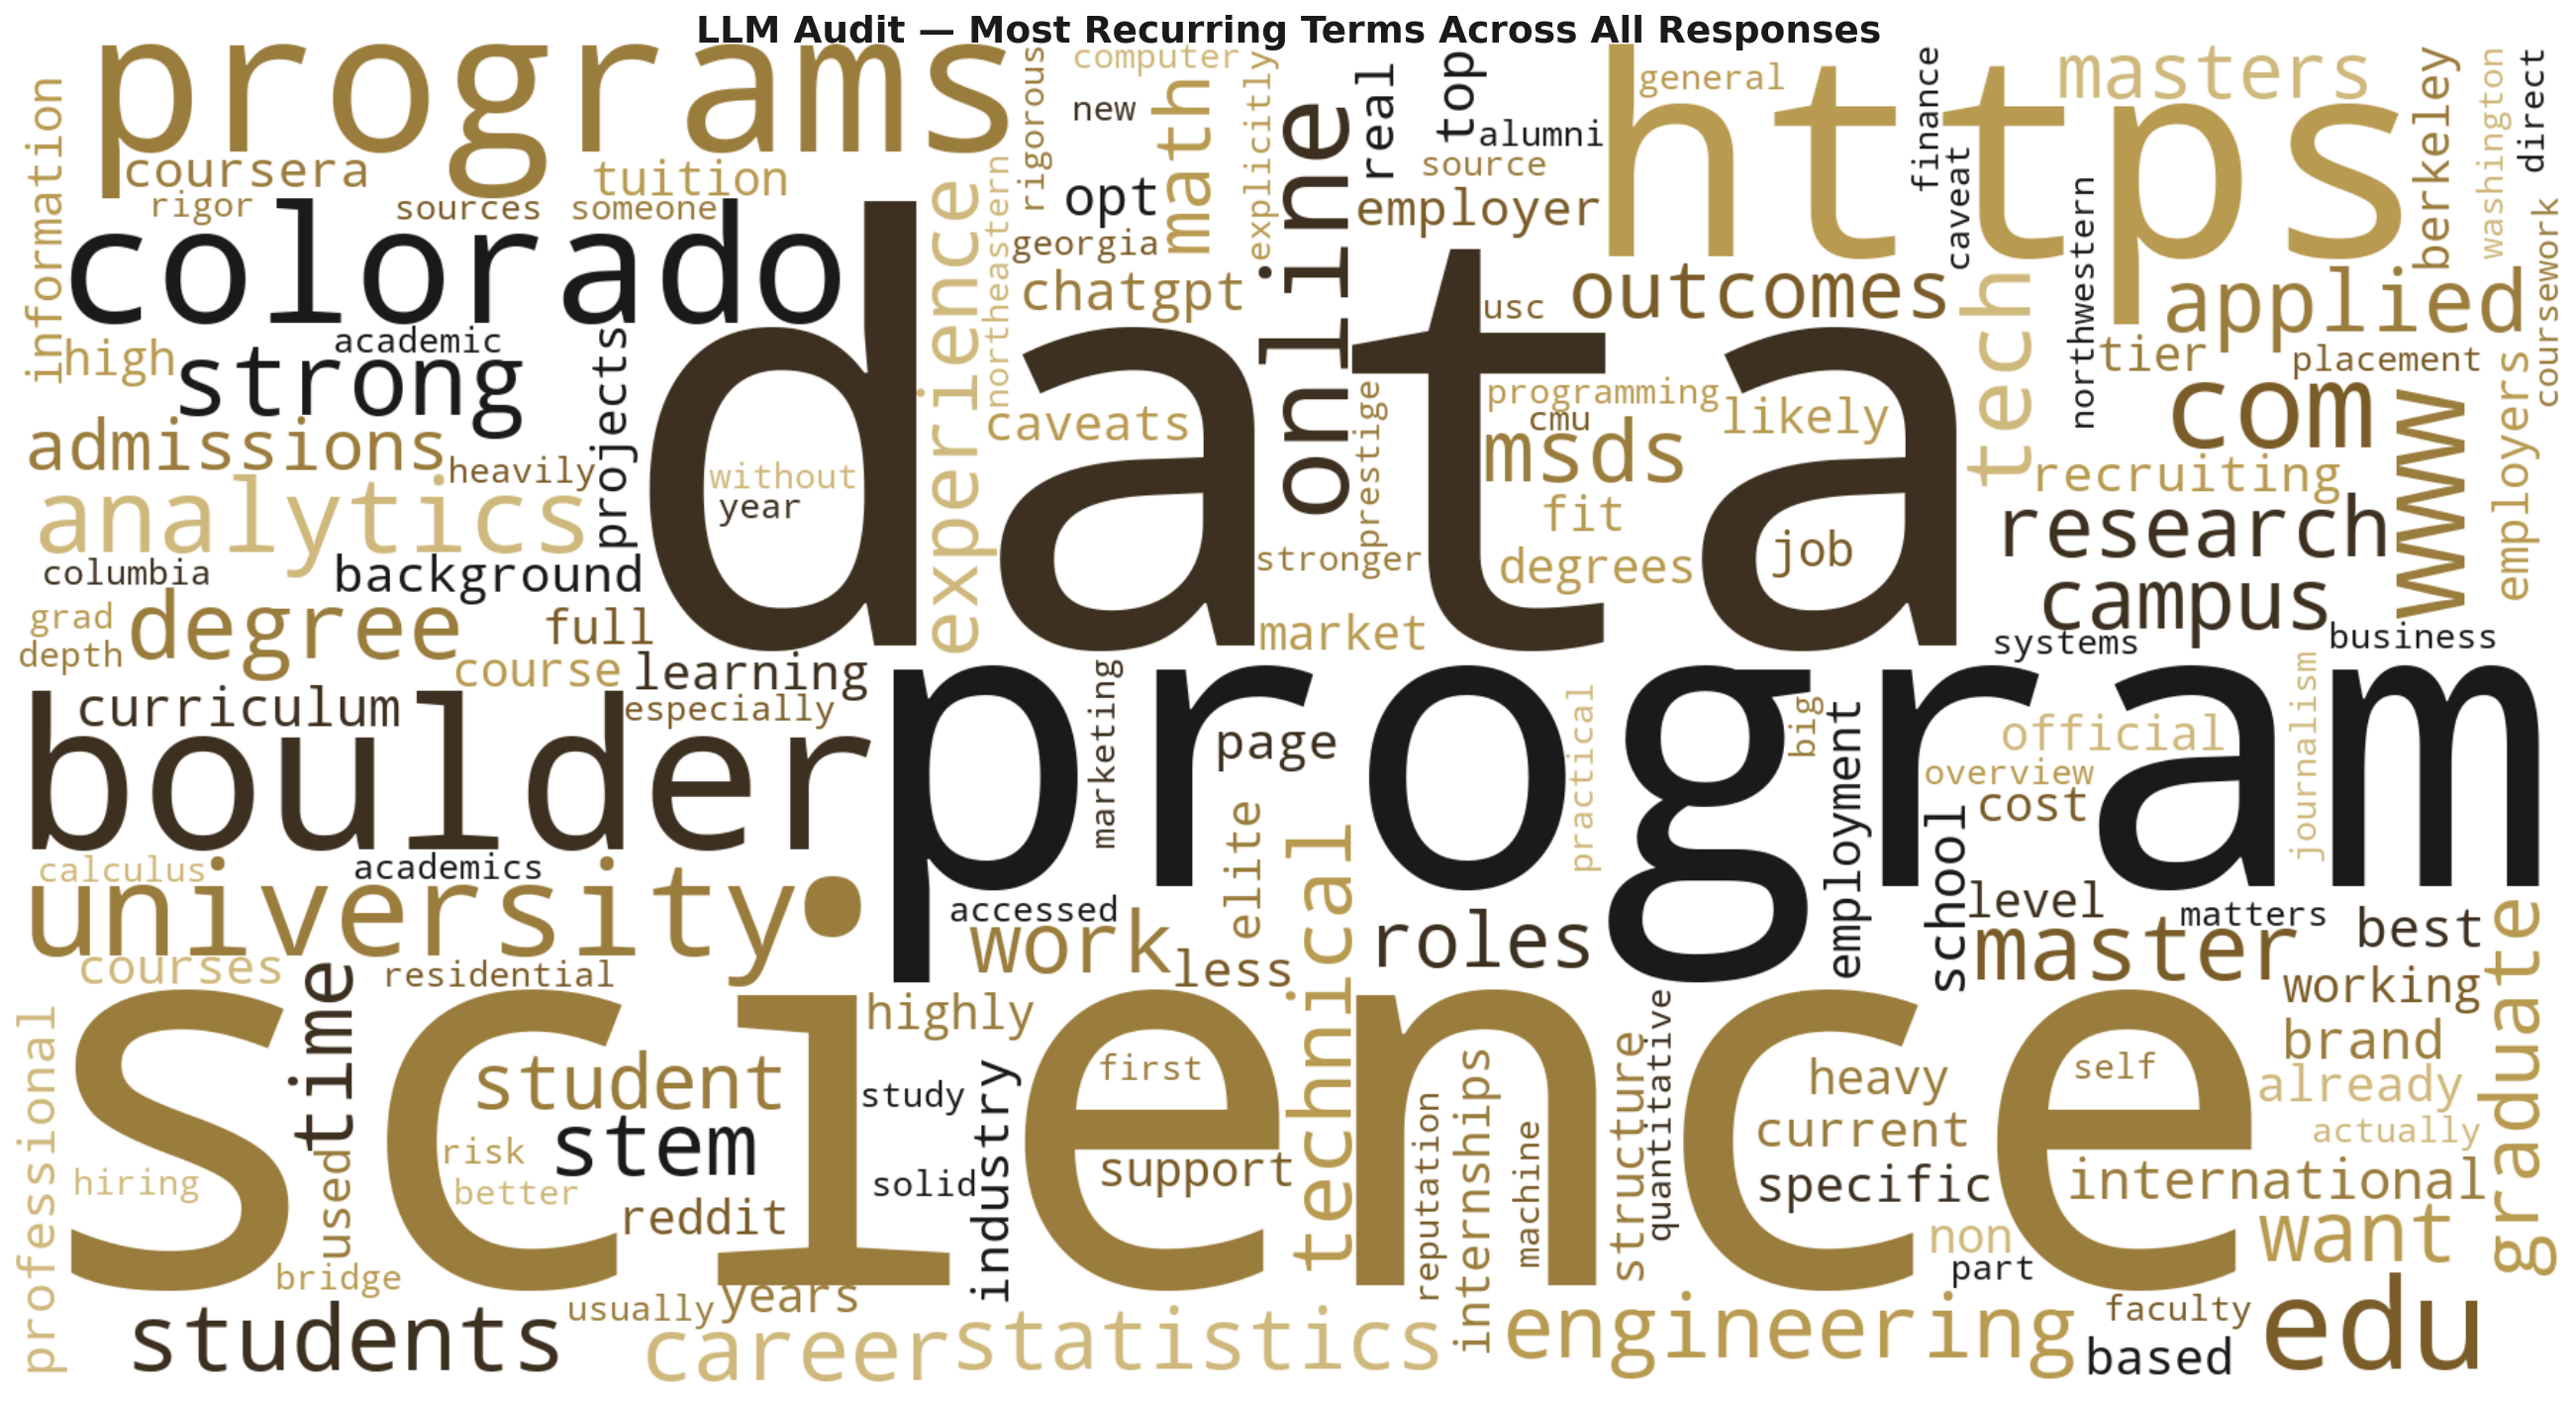

,Term,Count
1,programs,"1,170"
2,online,825
3,analytics,653
4,strong,591
5,tech,523
6,degree,520
7,master,511
8,students,508
9,stem,461
10,career,456


In [13]:

# ── CELL 10 — Word cloud + top-terms table ────────────────────
section("Word Cloud", "Most frequent terms across all LLM responses — sized by occurrence count", GOLD, "☁")

wc_path = ANLYS / "wordcloud.png"

if wc_path.exists():
    display(HTML("""
    <div style="border:1px solid #e2e8f0;border-radius:14px;overflow:hidden;
                box-shadow:0 6px 24px rgba(0,0,0,.09);margin-bottom:16px;">"""))
    display(Image(str(wc_path), width=900))
    display(HTML("</div>"))
else:
    try:
        from wordcloud import WordCloud as WC
        if wfreq:
            SKIP = {"data","science","ms","program","boulder","colorado","university",
                    "cu","https","utm","source","www","chatgpt","com","edu"}
            filtered = {k: v for k, v in wfreq.items() if k not in SKIP and len(k) > 2}

            def cu_color(*a, **k):
                import random
                return random.choice(["#CFB87C","#B89A50","#9A7C3C","#7A5C28",
                                      "#1a1a1a","#3d3020","#5a4010","#CFB87C"])

            wc_obj = WC(width=1800, height=900, background_color="white",
                        color_func=cu_color, max_words=150, min_font_size=10,
                        prefer_horizontal=0.80, collocations=False
                        ).generate_from_frequencies(filtered)

            fig_wc, ax = plt.subplots(figsize=(18, 9), dpi=100)
            ax.imshow(wc_obj, interpolation="bilinear")
            ax.axis("off")
            plt.tight_layout(pad=0)
            plt.savefig(wc_path, bbox_inches="tight", dpi=150, facecolor="white")
            plt.show()
            print(f"✓ Word cloud generated and saved → {wc_path}")
    except ImportError:
        display(HTML("""
        <div style="background:#fffbeb;border:1px solid #fde68a;border-radius:10px;
                    padding:16px 20px;color:#92400e;font-family:Segoe UI,Inter,sans-serif;">
          <b>⚠ wordcloud not installed.</b><br>
          Run <code>pip install wordcloud matplotlib</code> and re-execute this cell.
        </div>"""))

# ── Top-terms frequency table ─────────────────────────────────
if wfreq:
    SKIP_TABLE = {"data","science","ms","program","boulder","colorado","university",
                  "cu","https","utm","source","www","com","edu","chatgpt","gemini",
                  "perplexity","copilot","claude"}
    filtered_freq = {k: v for k, v in wfreq.items()
                     if k not in SKIP_TABLE and len(k) > 2}
    top30 = sorted(filtered_freq.items(), key=lambda x: x[1], reverse=True)[:30]
    top_df = pd.DataFrame(top30, columns=["Term","Count"])
    top_df.index = range(1, len(top_df) + 1)

    max_c = top_df["Count"].max()

    def style_row(row):
        intensity = row["Count"] / max_c
        r = int(207 - (207 - 154) * intensity)
        g = int(184 - (184 - 124) * intensity)
        b = int(124 - (124 - 60)  * intensity)
        return [f"background:rgba({r},{g},{b},0.28)"] * 2

    styled = (top_df.style
        .apply(style_row, axis=1)
        .format({"Count": "{:,}"})
        .set_table_styles([
            {"selector": "th",
             "props": [("background", "#1a1a1a"), ("color", "#CFB87C"),
                       ("font-weight", "700"), ("padding", "10px 18px"),
                       ("font-family", "Segoe UI,Inter,sans-serif"),
                       ("font-size","13px")]},
            {"selector": "td",
             "props": [("padding", "8px 18px"), ("font-size", "13px"),
                       ("font-family", "Segoe UI,Inter,sans-serif")]},
            {"selector": "table",
             "props": [("border-radius","10px"), ("overflow","hidden"),
                       ("border","1px solid #e2e8f0"), ("width","420px")]},
        ])
        .set_caption("Top 30 Terms (stopwords & brand names excluded)")
    )
    display(styled)
